# LIBRARIES IMPORTATION

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize

import warnings
warnings.filterwarnings("ignore")

In [2]:
pd.set_option("display.max.column", 20)

In [3]:
customer = pd.read_csv(r"C:\Users\DELL\OIBSIP\DataAnalytics-L1-EDARetailSales\customers.csv")

In [4]:
customer.head()

,customer_id,full_name,age,gender,email,phone,street_address,city,state,zip_code,registration_date,preferred_channel
0,4c30e132-0704-4459-a509-9eddde934977,Mark Johnson,40.0,Male,mark.johnson@yahoo.com,989.608.3863,819 Johnson Course,Houston,Texas,29158.0,4/25/2024,NaN
1,68bec407-275f-4b5b-9a82-13d02f54626a,Robert Smith,33.0,Male,smithr@yahoo.com,(518)349-5931x0341,35116 Michael Key Suite 078,Austin,Texas,16862.0,5/30/2021,in-store
2,4466459f-76c8-433c-814e-6d59cb4131fc,Jamie Chavez,42.0,Female,jchavez@gmail.com,364.583.5030x564,419 Amanda Gardens,Detroit,Michigan,21918.0,12/14/2023,online
3,04c36a25-02f3-462c-92b0-6bf291c57706,Thomas Bradley,53.0,Male,thomas.bradley@hotmail.com,(332)887-1012x269,7242 Julie Plain Suite 969,Fort Worth,Texas,52851.0,7/11/2022,both
4,e916df3d-c3f5-40b0-8ae2-5d043be88300,Jane Ferrell,32.0,Female,jane.ferrell@hotmail.com,5484281489,845 Kelly Estate,Atlanta,Georgia,59971.0,9/6/2020,online


In [5]:
cus_df = customer.copy()

In [6]:
cus_df.head()

,customer_id,full_name,age,gender,email,phone,street_address,city,state,zip_code,registration_date,preferred_channel
0,4c30e132-0704-4459-a509-9eddde934977,Mark Johnson,40.0,Male,mark.johnson@yahoo.com,989.608.3863,819 Johnson Course,Houston,Texas,29158.0,4/25/2024,NaN
1,68bec407-275f-4b5b-9a82-13d02f54626a,Robert Smith,33.0,Male,smithr@yahoo.com,(518)349-5931x0341,35116 Michael Key Suite 078,Austin,Texas,16862.0,5/30/2021,in-store
2,4466459f-76c8-433c-814e-6d59cb4131fc,Jamie Chavez,42.0,Female,jchavez@gmail.com,364.583.5030x564,419 Amanda Gardens,Detroit,Michigan,21918.0,12/14/2023,online
3,04c36a25-02f3-462c-92b0-6bf291c57706,Thomas Bradley,53.0,Male,thomas.bradley@hotmail.com,(332)887-1012x269,7242 Julie Plain Suite 969,Fort Worth,Texas,52851.0,7/11/2022,both
4,e916df3d-c3f5-40b0-8ae2-5d043be88300,Jane Ferrell,32.0,Female,jane.ferrell@hotmail.com,5484281489,845 Kelly Estate,Atlanta,Georgia,59971.0,9/6/2020,online


In [7]:
cus_df.shape

(5000, 12)

In [8]:
cus_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        5000 non-null   object 
 1   full_name          4894 non-null   object 
 2   age                4814 non-null   float64
 3   gender             4888 non-null   object 
 4   email              4889 non-null   object 
 5   phone              4814 non-null   object 
 6   street_address     4823 non-null   object 
 7   city               4903 non-null   object 
 8   state              4907 non-null   object 
 9   zip_code           4904 non-null   float64
 10  registration_date  5000 non-null   object 
 11  preferred_channel  4886 non-null   object 
dtypes: float64(2), object(10)
memory usage: 468.9+ KB


After checking details about this dataset, here is what i identified:
1. There are 5,000 enteries and 12 columns.
2. There are missing values in about 10 columns except from customer_id and preferred_channel column, mismatched datatype in age and registration_date columns.
3. Age is an object instead of an integer, registration_date is an object but it's supposed to be a datetime datatype. 

# Data Cleaning

In [9]:
duplicate_values = cus_df.duplicated().sum()
duplicate_values

0

In [10]:
missing_values = cus_df.isna().sum()
missing_values

customer_id            0
full_name            106
age                  186
gender               112
email                111
phone                186
street_address       177
city                  97
state                 93
zip_code              96
registration_date      0
preferred_channel    114
dtype: int64

In [11]:
cus_df["city"].unique()

array(['Houston', 'Austin', 'Detroit', 'Fort Worth', 'Atlanta',
       'San Francisco', 'Tempe', 'Tucson', 'New York City', 'Syracuse',
       'Columbus', 'Seattle', 'Macon', 'Arlington', 'Sacramento',
       'Champaign', 'Miami', 'Springfield', 'Toledo', 'Richmond',
       'Orlando', 'Phoenix', 'Trenton', 'Buffalo', 'Greensboro',
       'Rochester', 'Pittsburgh', 'Allentown', 'Savannah', 'Erie',
       'San Diego', 'Lowell', 'Virginia Beach', 'San Antonio',
       'Charlotte', 'Cincinnati', 'Vancouver', 'Philadelphia', 'Albany',
       'Tallahassee', 'Grand Rapids', 'Newark', 'Elizabeth', 'Flint',
       'Tampa', 'Jacksonville', 'Norfolk', 'Lansing', 'Chicago',
       'Los Angeles', 'Harrisburg', 'San Jose', 'Raleigh', 'Alexandria',
       'Tacoma', 'Augusta', 'Mesa', 'Worcester', 'Cambridge', 'Dallas',
       nan, 'Scottsdale', 'Bellevue', 'Spokane', 'Peoria', 'Rockford',
       'Ann Arbor', 'Athens', 'Durham', 'Akron', 'Cleveland',
       'Winston-Salem', 'Boston', 'Paterson', 'Jers

In [12]:
cus_df["city"].fillna("Unknown", inplace = True)

In [13]:
cus_df["state"].unique()

array(['Texas', 'Michigan', 'Georgia', 'California', 'Arizona',
       'New York', 'Ohio', 'Washington', 'Virginia', 'Illinois',
       'Florida', 'Massachusetts', 'New Jersey', 'North Carolina',
       'Pennsylvania', nan], dtype=object)

In [14]:
cus_df["state"].value_counts()

state
California        873
Texas             644
Florida           542
New York          469
Illinois          294
Pennsylvania      294
Ohio              258
Georgia           247
North Carolina    226
Michigan          208
Virginia          198
New Jersey        172
Washington        166
Arizona           159
Massachusetts     157
Name: count, dtype: int64

In [15]:
cus_df["state"].fillna("California", inplace = True)

In [16]:
cus_df.dropna(subset = ["zip_code"], inplace = True)

In [17]:
cus_df["preferred_channel"].unique()

array([nan, 'in-store', 'online', 'both'], dtype=object)

In [18]:
cus_df["preferred_channel"].value_counts(normalize = True)

preferred_channel
online      0.504903
both        0.298352
in-store    0.196745
Name: proportion, dtype: float64

In [19]:
cus_df["preferred_channel"].value_counts()

preferred_channel
online      2420
both        1430
in-store     943
Name: count, dtype: int64

In [20]:
cus_df["preferred_channel"].fillna("online", inplace = True)

In [21]:
cus_df["gender"].unique()

array(['Male', 'Female', 'Non-binary', 'Prefer not to say', nan],
      dtype=object)

In [22]:
cus_df["gender"].fillna("Unknown", inplace = True)

In [23]:
cus_df["age"].median()

35.0

In [24]:
cus_df["age"].fillna(cus_df["age"].median(), inplace = True)

In [25]:
cus_df["age"] = cus_df["age"].astype("int64")

In [26]:
cus_df["zip_code"] = cus_df["zip_code"].astype("int64").astype("string")

In [27]:
cus_df["registration_date"] = pd.to_datetime(cus_df["registration_date"], errors = "coerce")

In [28]:
duplicate_values = cus_df.duplicated().sum()
duplicate_values

0

In [29]:
missing_values = cus_df.isna().sum()
missing_values

customer_id            0
full_name            106
age                    0
gender                 0
email                105
phone                183
street_address       174
city                   0
state                  0
zip_code               0
registration_date      0
preferred_channel      0
dtype: int64

In [30]:
cus_df["phone"] = cus_df["phone"].astype("string")

In [31]:
# Extract extension
cus_df['extension'] = cus_df['phone'].str.extract(r'[xX](\d+)', expand = False)

In [32]:
# Remove extension
cus_df['phone_clean'] = cus_df['phone'].str.replace(r'[xX]\d+', '', regex = True)

In [33]:
# Remove brackets, spaces, dots, hyphens, +
cus_df['phone_clean'] = cus_df['phone_clean'].str.replace(r'\D', '', regex = True)

This remove spaces, hyphens and bracket from phone numbers.

In [34]:
# Turn empty strings into missing values
cus_df['phone_clean'] = cus_df['phone_clean'].replace('', pd.NA)

In [35]:
# Validate standard 10-digit numbers
cus_df['phone_valid'] = cus_df['phone_clean'].str.fullmatch(r'\d{10}')

In [36]:
cus_df["phone_clean"]

0          9896083863
1          5183495931
2          3645835030
3          3328871012
4          5484281489
            ...      
4995       4003782734
4996    0014478395231
4997    0015499784978
4998       6663090883
4999       6372040842
Name: phone_clean, Length: 4904, dtype: string

In [37]:
# Handle 11-digit numbers beginning with 1
cus_df.loc[
    cus_df['phone_clean'].str.fullmatch(r'1\d{10}', na = False), 'phone_clean'] = cus_df['phone_clean'].str[1:]

In [38]:
# Handle 13-digit numbers beginning with 001
cus_df.loc[
    cus_df['phone_clean'].str.fullmatch(r'001\d{10}', na = False),'phone_clean'] = cus_df['phone_clean'].str[3:]

In [39]:
# Anything that isn't exactly 10 digits becomes missing
cus_df.loc[
    ~cus_df['phone_clean'].str.fullmatch(r'\d{10}', na = False), 'phone_clean'] = pd.NA

In [40]:
cus_df['phone_clean']

0       9896083863
1       5183495931
2       3645835030
3       3328871012
4       5484281489
           ...    
4995    4003782734
4996    4478395231
4997    5499784978
4998    6663090883
4999    6372040842
Name: phone_clean, Length: 4904, dtype: string

In [41]:
cus_df['phone_clean'].str.len().value_counts(dropna = False)

phone_clean
10      4558
<NA>     346
Name: count, dtype: Int64

In [42]:
cus_df[cus_df['phone_clean'].isna()][['phone', 'phone_clean']]

,phone,phone_clean
7,<NA>,<NA>
37,-11121,<NA>
43,-7004,<NA>
51,<NA>,<NA>
61,<NA>,<NA>
...,...,...
4960,<NA>,<NA>
4962,-9879,<NA>
4967,-6859,<NA>
4984,-5584,<NA>


In [43]:
cus_df['phone_clean'] = cus_df['phone_clean'].str.replace(
    r'(\d{3})(\d{3})(\d{4})', r'\1-\2-\3', regex = True)

This code takes the values in the `phone_clean` column and **reformats 10-digit phone numbers into the `XXX-XXX-XXXX` format**. The regular expression `r'(\d{3})(\d{3})(\d{4})'` splits the phone number into three groups: the first 3 digits, the next 3 digits, and the final 4 digits. Then `r'\1-\2-\3'` puts those groups back together with hyphens between them. For example, `0801234567` would become `080-123-4567`. `regex=True` tells Pandas to treat the first argument as a regular expression.


In [44]:
cus_df['preferred_channel'] = cus_df['preferred_channel'].str.title()
# To convert values to proper case.

In [45]:
cus_df.head()

,customer_id,full_name,age,gender,email,phone,street_address,city,state,zip_code,registration_date,preferred_channel,extension,phone_clean,phone_valid
0,4c30e132-0704-4459-a509-9eddde934977,Mark Johnson,40,Male,mark.johnson@yahoo.com,989.608.3863,819 Johnson Course,Houston,Texas,29158,2024-04-25,Online,<NA>,989-608-3863,True
1,68bec407-275f-4b5b-9a82-13d02f54626a,Robert Smith,33,Male,smithr@yahoo.com,(518)349-5931x0341,35116 Michael Key Suite 078,Austin,Texas,16862,2021-05-30,In-Store,0341,518-349-5931,True
2,4466459f-76c8-433c-814e-6d59cb4131fc,Jamie Chavez,42,Female,jchavez@gmail.com,364.583.5030x564,419 Amanda Gardens,Detroit,Michigan,21918,2023-12-14,Online,564,364-583-5030,True
3,04c36a25-02f3-462c-92b0-6bf291c57706,Thomas Bradley,53,Male,thomas.bradley@hotmail.com,(332)887-1012x269,7242 Julie Plain Suite 969,Fort Worth,Texas,52851,2022-07-11,Both,269,332-887-1012,True
4,e916df3d-c3f5-40b0-8ae2-5d043be88300,Jane Ferrell,32,Female,jane.ferrell@hotmail.com,5484281489,845 Kelly Estate,Atlanta,Georgia,59971,2020-09-06,Online,<NA>,548-428-1489,True


In [46]:
cus_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4904 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        4904 non-null   object        
 1   full_name          4798 non-null   object        
 2   age                4904 non-null   int64         
 3   gender             4904 non-null   object        
 4   email              4799 non-null   object        
 5   phone              4721 non-null   string        
 6   street_address     4730 non-null   object        
 7   city               4904 non-null   object        
 8   state              4904 non-null   object        
 9   zip_code           4904 non-null   string        
 10  registration_date  4904 non-null   datetime64[ns]
 11  preferred_channel  4904 non-null   object        
 12  extension          2833 non-null   string        
 13  phone_clean        4558 non-null   string        
 14  phone_valid  

In [47]:
trans = pd.read_csv(r"C:\Users\DELL\OIBSIP\DataAnalytics-L1-EDARetailSales\transactions.csv")

In [48]:
trans_df = trans.copy()

In [49]:
trans_df.head()

,transaction_id,customer_id,product_name,product_category,quantity,price,transaction_date,store_location,payment_method,discount_applied
0,53e3d9f5-6231-46de-aa39-e5f8eaae2eee,727839b2-f084-4e94-94d8-ae59cc8e4b84,Ring Doorbell,Smart Home Devices,1.0,140.07,12/6/2020,"Houston, TX",Credit Card,20.0
1,ae6e6edf-f2fe-45c8-989c-c01e77eade0c,c4ac244c-989e-46fb-b243-91dd1d5cf739,Oculus Quest,Gaming Consoles,1.0,339.57,4/26/2021,Online,Gift Card,0.0
2,ba85240a-2b5d-4987-ac0a-efb6a4a57d6d,d296bf0d-92bb-4670-a578-2fd3553cf7c8,Samsung Galaxy S22,Smartphones,2.0,1335.88,10/28/2021,Online,PayPal,30.0
3,3725a285-2a2b-4a80-b317-7c8041cd9b8b,7b1b9980-9d65-40fc-8ad6-6afaae4699e4,External Hard Drive,Computer Accessories,1.0,91.56,3/16/2023,Online,Credit Card,25.0
4,de1b05a5-68c7-4b00-a068-e8c2f13f0dab,8595dcfa-2bfc-46f4-a15a-042af85b78cd,MacBook Pro,Laptops,1.0,985.15,8/30/2022,"Atlanta, GA",Credit Card,0.0


In [50]:
trans_df.shape

(32295, 10)

In [51]:
trans_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32295 entries, 0 to 32294
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    32295 non-null  object 
 1   customer_id       32295 non-null  object 
 2   product_name      31617 non-null  object 
 3   product_category  31609 non-null  object 
 4   quantity          31651 non-null  float64
 5   price             31673 non-null  float64
 6   transaction_date  32295 non-null  object 
 7   store_location    31651 non-null  object 
 8   payment_method    31635 non-null  object 
 9   discount_applied  31684 non-null  float64
dtypes: float64(3), object(7)
memory usage: 2.5+ MB


In [52]:
trans_df.isna().sum()

transaction_id        0
customer_id           0
product_name        678
product_category    686
quantity            644
price               622
transaction_date      0
store_location      644
payment_method      660
discount_applied    611
dtype: int64

In [53]:
# Inspect this column
trans_df["product_name"].head(20)


0                Ring Doorbell
1                 Oculus Quest
2           Samsung Galaxy S22
3          External Hard Drive
4                  MacBook Pro
5                   Range Hood
6                   Range Hood
7        JBL Bluetooth Speaker
8                         Sofa
9                          NaN
10                   Air Fryer
11                    Area Rug
12                     Blender
13                    Wall Art
14                         NaN
15                 Google Nest
16                    Curtains
17    Audio-Technica Turntable
18             Nintendo Switch
19                  Table Lamp
Name: product_name, dtype: object

In [54]:
# Then check what other information is available in those rows with missing product name:
trans_df[trans_df["product_name"].isna()][
    ['product_category', 'quantity', 'price', 'store_location', 'payment_method', 'discount_applied']
].head(20)

,product_category,quantity,price,store_location,payment_method,discount_applied
9,Kitchen Appliances,1.0,1033.261129,Online,Debit Card,10.0
14,Home Decor,2.0,312.730000,Online,Credit Card,15.0
44,Smart Home Devices,2.0,NaN,Online,Credit Card,15.0
63,Home Decor,1.0,145.270000,Online,Debit Card,0.0
68,Audio Equipment,1.0,203.240000,Online,Google Pay,0.0
88,Audio Equipment,1.0,300.860000,"Seattle, WA",Credit Card,5.0
155,Desktop Computers,1.0,1820.510000,Online,Apple Pay,30.0
361,Audio Equipment,1.0,286.580000,Online,Debit Card,0.0
463,Furniture,2.0,720.810000,"Atlanta, GA",Cash,0.0
532,Smart Home Devices,2.0,143.280000,NaN,Credit Card,0.0


In [55]:
trans_df['quantity'].describe()

count    31651.000000
mean         1.438564
std          2.160827
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         50.000000
Name: quantity, dtype: float64

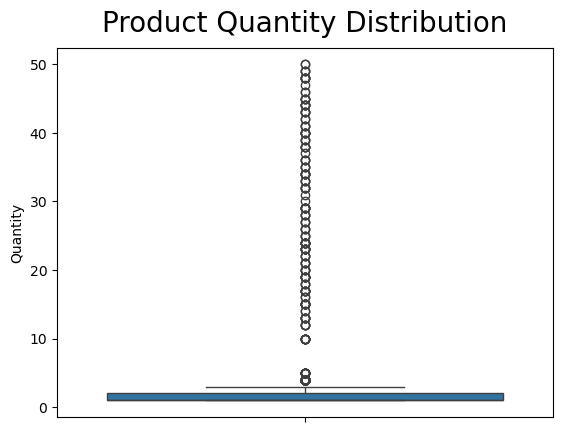

In [56]:
g = sns.boxplot(y = "quantity", data = trans_df)
g.set_title("Product Quantity Distribution", fontsize = 20, y = 1.02)
g.set_ylabel("Quantity")
plt.show()

In [57]:
trans_df["quantity"].fillna(trans_df["quantity"].median(), inplace = True)

I used the **median** because the quantity data is **skewed and contains extreme values**, such as 50. The median is less affected by these outliers than the mean.


In [58]:
# Checking whether the missing product category can be retrived from product name.
trans_df[trans_df['product_category'].isna()][['product_name']].head(20)

,product_name
17,Audio-Technica Turntable
36,Blender
48,Steam Deck
106,Wall Art
138,Asus ROG
163,iPhone 13
229,Xiaomi Mi 12
347,Wall Art
504,Cookware Set
587,Curtains


In [59]:
trans_df.groupby('product_name')['product_category'].agg(
    lambda x: x.dropna().unique()
).loc[['Audio-Technica Turntable', 'Blender', 'Steam Deck',
     'Wall Art', 'Asus ROG', 'iPhone 13', 'Xiaomi Mi 12']]

product_name
Audio-Technica Turntable             [Audio Equipment]
Blender                     [Small Kitchen Appliances]
Steam Deck                           [Gaming Consoles]
Wall Art                                  [Home Decor]
Asus ROG                           [Desktop Computers]
iPhone 13                                [Smartphones]
Xiaomi Mi 12                             [Smartphones]
Name: product_category, dtype: object

In [60]:
category_map = trans_df.groupby('product_name')['product_category'].first()

trans_df['product_category'] = trans_df['product_category'].fillna(
    trans_df['product_name'].map(category_map))

In [61]:
trans_df['product_category'].isna().sum()

19

The category that are still missing indicates that the product names are missing.

In [62]:
trans_df["price"].fillna(trans_df["price"].median(), inplace = True)

In [63]:
trans_df['discount_applied'].describe()

count    31684.000000
mean         5.255018
std          9.280936
min          0.000000
25%          0.000000
50%          0.000000
75%         10.000000
max         30.000000
Name: discount_applied, dtype: float64

In [64]:
# I will be replacing NANs with 0 because it means there was no discount and 0 is actually the mean.
trans_df["discount_applied"].fillna(trans_df["discount_applied"].median(), inplace = True)

In [65]:
trans_df.isna().sum()

transaction_id        0
customer_id           0
product_name        678
product_category     19
quantity              0
price                 0
transaction_date      0
store_location      644
payment_method      660
discount_applied      0
dtype: int64

In [66]:
trans_df["store_location"].unique()

array(['Houston, TX', 'Online', 'Atlanta, GA', 'Boston, MA', 'Denver, CO',
       'Miami, FL', 'Chicago, IL', 'Seattle, WA', 'New York, NY',
       'San Francisco, CA', 'Los Angeles, CA', nan], dtype=object)

In [67]:
trans_df["store_location"].value_counts()

store_location
Online               16108
Houston, TX           1630
Miami, FL             1587
San Francisco, CA     1579
Atlanta, GA           1563
New York, NY          1562
Chicago, IL           1559
Seattle, WA           1536
Denver, CO            1529
Boston, MA            1528
Los Angeles, CA       1470
Name: count, dtype: int64

In [68]:
trans_df["store_location"].fillna("Unknown", inplace = True)

In [69]:
trans_df["payment_method"].fillna("Unknown", inplace = True)

In [70]:
trans_df = trans_df.dropna(subset = ['product_category'])

In [71]:
trans_df["product_name"].fillna("Unknown", inplace = True)

In [72]:
trans_df["transaction_date"] = pd.to_datetime(trans_df["transaction_date"], errors = "coerce")

In [73]:
cus_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4904 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        4904 non-null   object        
 1   full_name          4798 non-null   object        
 2   age                4904 non-null   int64         
 3   gender             4904 non-null   object        
 4   email              4799 non-null   object        
 5   phone              4721 non-null   string        
 6   street_address     4730 non-null   object        
 7   city               4904 non-null   object        
 8   state              4904 non-null   object        
 9   zip_code           4904 non-null   string        
 10  registration_date  4904 non-null   datetime64[ns]
 11  preferred_channel  4904 non-null   object        
 12  extension          2833 non-null   string        
 13  phone_clean        4558 non-null   string        
 14  phone_valid  

In [74]:
cus_df.duplicated().sum()

0

In [75]:
trans_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32276 entries, 0 to 32294
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    32276 non-null  object        
 1   customer_id       32276 non-null  object        
 2   product_name      32276 non-null  object        
 3   product_category  32276 non-null  object        
 4   quantity          32276 non-null  float64       
 5   price             32276 non-null  float64       
 6   transaction_date  32276 non-null  datetime64[ns]
 7   store_location    32276 non-null  object        
 8   payment_method    32276 non-null  object        
 9   discount_applied  32276 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(6)
memory usage: 2.7+ MB


In [76]:
trans_df.duplicated().sum()

0

In [77]:
cus_df.columns

Index(['customer_id', 'full_name', 'age', 'gender', 'email', 'phone',
       'street_address', 'city', 'state', 'zip_code', 'registration_date',
       'preferred_channel', 'extension', 'phone_clean', 'phone_valid'],
      dtype='object')

In [78]:
cus_df.drop(columns = ['full_name', 'email', 'phone', 'street_address', 'zip_code',
                       'registration_date', 'extension', 'phone_clean', 'phone_valid'], inplace = True)

In [79]:
cus_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4904 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        4904 non-null   object
 1   age                4904 non-null   int64 
 2   gender             4904 non-null   object
 3   city               4904 non-null   object
 4   state              4904 non-null   object
 5   preferred_channel  4904 non-null   object
dtypes: int64(1), object(5)
memory usage: 397.2+ KB


In [80]:
df = trans_df.merge(cus_df, on = "customer_id", how = "left")

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32276 entries, 0 to 32275
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   transaction_id     32276 non-null  object        
 1   customer_id        32276 non-null  object        
 2   product_name       32276 non-null  object        
 3   product_category   32276 non-null  object        
 4   quantity           32276 non-null  float64       
 5   price              32276 non-null  float64       
 6   transaction_date   32276 non-null  datetime64[ns]
 7   store_location     32276 non-null  object        
 8   payment_method     32276 non-null  object        
 9   discount_applied   32276 non-null  float64       
 10  age                31619 non-null  float64       
 11  gender             31619 non-null  object        
 12  city               31619 non-null  object        
 13  state              31619 non-null  object        
 14  prefer

In [82]:
df = df.dropna(subset = ['age', 'gender', 'city', 'state', 'preferred_channel'])

eason: The missing customer information occurs in the same small set of rows, so dropping them avoids making up customer details and has minimal impact on the analysis.

In [83]:
df.isna().sum()

transaction_id       0
customer_id          0
product_name         0
product_category     0
quantity             0
price                0
transaction_date     0
store_location       0
payment_method       0
discount_applied     0
age                  0
gender               0
city                 0
state                0
preferred_channel    0
dtype: int64

In [84]:
df.duplicated().sum()

0

In [85]:
df["city"].unique()

array(['Miami', 'San Antonio', 'Unknown', 'Pittsburgh', 'San Jose',
       'Scottsdale', 'Spokane', 'Allentown', 'Springfield', 'Toledo',
       'Cincinnati', 'Macon', 'Trenton', 'Flint', 'Rochester',
       'San Francisco', 'Newark', 'Sacramento', 'Jacksonville',
       'Savannah', 'Ann Arbor', 'New York City', 'Chicago', 'Alexandria',
       'Austin', 'Fort Worth', 'Los Angeles', 'Raleigh', 'Philadelphia',
       'Columbus', 'Cambridge', 'Syracuse', 'Elizabeth', 'Buffalo',
       'Dallas', 'Lansing', 'Worcester', 'San Diego', 'Erie', 'Rockford',
       'Orlando', 'Mesa', 'Tallahassee', 'Harrisburg', 'Detroit',
       'Paterson', 'Seattle', 'Houston', 'Athens', 'Tucson', 'Tampa',
       'Richmond', 'Albany', 'Tacoma', 'Virginia Beach', 'Akron',
       'Vancouver', 'Arlington', 'Atlanta', 'Greensboro', 'Charlotte',
       'Tempe', 'Winston-Salem', 'Bellevue', 'Phoenix', 'Norfolk',
       'Cleveland', 'Champaign', 'Augusta', 'Durham', 'Lowell',
       'Grand Rapids', 'Jersey City', 'Peo

In [86]:
df["age"].unique()

array([33., 18., 40., 26., 31., 45., 22., 44., 51., 38., 70., 35., 23.,
       53., 27., 37., 32., 28., 25., 41., 50., 30., 47., 49., 46., 54.,
       73., 34., 24., 43., 19., 57., 36., 48., 42., 21., 52., 68., 39.,
       29., 56., 58., 20., 65., 55., 59., 63., 60., 61., 64., 67., 66.,
       62., 71., 72., 80., 69.])

In [87]:
df["state"].unique()

array(['Florida', 'Texas', 'Virginia', 'Pennsylvania', 'California',
       'Arizona', 'Washington', 'Illinois', 'Ohio', 'Georgia',
       'New Jersey', 'Michigan', 'New York', 'North Carolina',
       'Massachusetts'], dtype=object)

In [88]:
df["payment_method"].unique()

array(['Credit Card', 'Gift Card', 'PayPal', 'Debit Card', 'Apple Pay',
       'Cash', 'Unknown', 'Google Pay'], dtype=object)